# Descrição do Dataset ArtBench


## 1. Imports

In [12]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from torchvision import transforms

from artbench_dataset import ArtBenchDataset, DATASET_PATH, download_artbench

## 2. Extrair Dataset

In [13]:
download_artbench()

A iniciar download do ArtBench...
Dataset URL: https://www.kaggle.com/datasets/alexanderliao/artbench10
artbench10.zip: Skipping, found more recently modified local copy (use --force to force download)
A extrair dataset...
Dataset pronto em: data/artbench-10-python e data/artbench-10-binary


In [14]:
print(DATASET_PATH.resolve())

D:\MESTRADO\1º Ano\2º Semestre\IAG\PROJETO_TENTATIVA1\data\artbench-10-python\artbench-10-batches-py


## 3. Ver caracteristica do dataset

Este notebook reutiliza o loader definido em `artbench_dataset.py`.

In [15]:
raw_dataset = ArtBenchDataset(DATASET_PATH, transform=None, train=True)
raw_image, _ = raw_dataset[0]
original_image_size = raw_image.size
print("Tamanho original da imagem:", original_image_size)

Tamanho original da imagem: (32, 32)


In [19]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])


dataset = ArtBenchDataset(DATASET_PATH, transform=transform, train=True)
sample_image, _ = dataset[0]
image_size = tuple(sample_image.shape)

print("Número total de imagens:", len(dataset))
print("Número de classes:", len(dataset.classes))
print("\nClasses:")
for i, cls in enumerate(dataset.classes):
    print(f"{i}: {cls}")

Número total de imagens: 50000
Número de classes: 10

Classes:
0: impressionism
1: realism
2: romanticism
3: expressionism
4: baroque
5: post_impressionism
6: art_nouveau
7: surrealism
8: ukiyo_e
9: renaissance


## 4. Ver algumas amostras, uma de cada classe

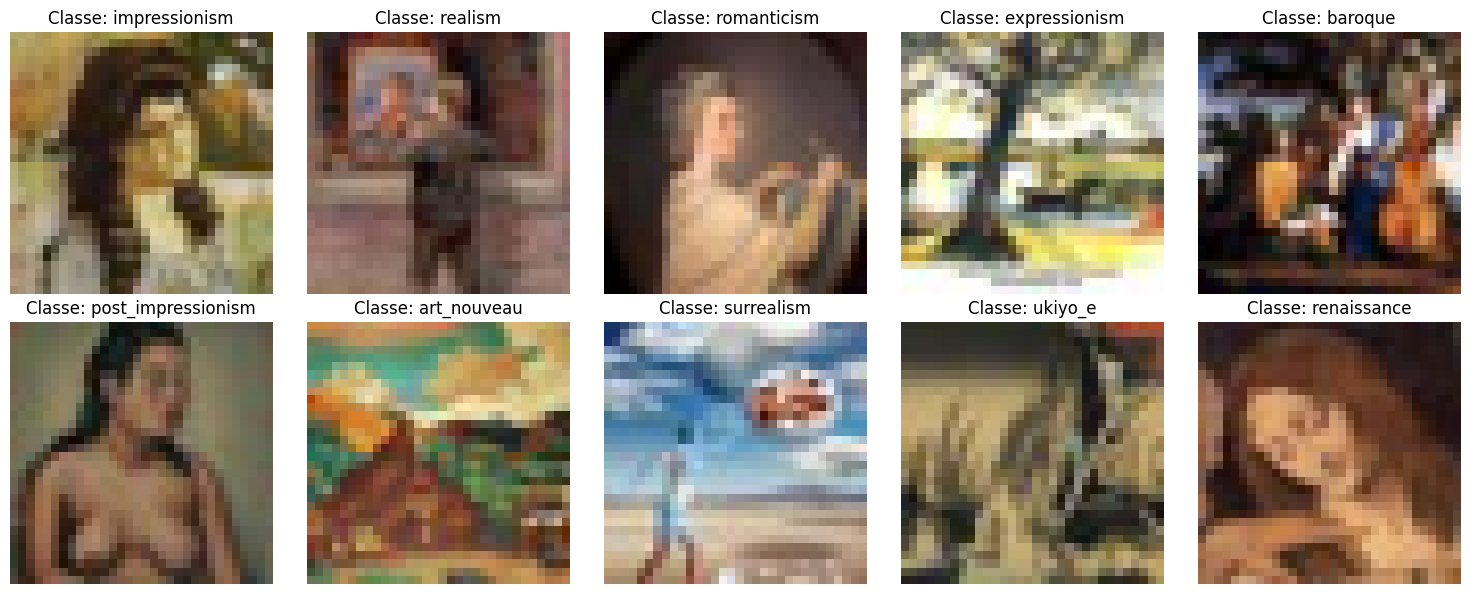

In [20]:
class_indices = {}
for idx, label in enumerate(dataset.labels):
    if label not in class_indices:
        class_indices[label] = idx
    if len(class_indices) == len(dataset.classes):
        break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for class_id, ax in enumerate(axes):
    idx = class_indices[class_id]
    image, label = dataset[idx]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"Classe: {dataset.classes[label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Distribuição das classes

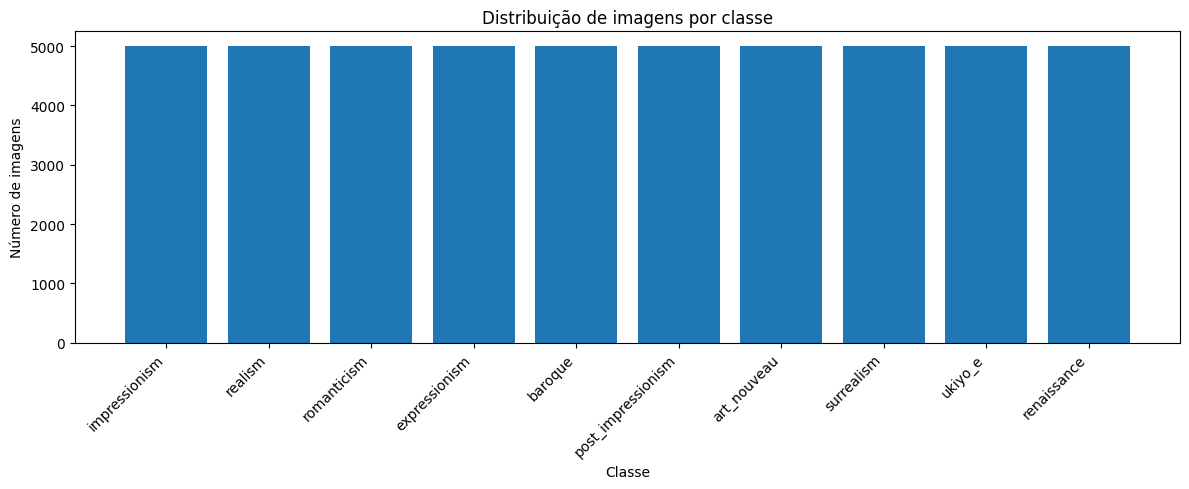

In [21]:
labels = [label for _, label in dataset.samples]
class_counts = Counter(labels)

distribution_df = pd.DataFrame({
    "class_id": sorted(class_counts.keys()),
    "class_name": [dataset.classes[i] for i in sorted(class_counts.keys())],
    "count": [class_counts[i] for i in sorted(class_counts.keys())]
})

plt.figure(figsize=(12, 5))
plt.bar(distribution_df["class_name"], distribution_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribuição de imagens por classe")
plt.xlabel("Classe")
plt.ylabel("Número de imagens")
plt.tight_layout()
plt.show()